### Import required packages

In [5]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image

### Check hardware

In [6]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using GPU: {torch.cuda.get_device_name(0)}')
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'Using MPS: {torch.mps.is_available()}')

else:
    device = torch.device('cpu')
    print('Using CPU')

Using GPU: NVIDIA GeForce GTX 1660 SUPER
Memory: 6.44 GB


### Load IAM dataset

In [7]:
from pathlib import Path
from torch.utils.data import random_split

iam_path = "data/raw/"

required_files = [
    "ascii/lines.txt",
    "lines/"
]


for file in required_files:
    file_path = Path(iam_path) / file
    if not file_path.exists():
        raise FileNotFoundError(f"Не найден обязательный путь: {file_path}")
    if file_path.is_dir():
        files_count = sum(1 for p in file_path.rglob("*") if p.is_file())
        if files_count == 0:
            raise FileNotFoundError(f"Папка пуста: {file_path}")
        print(f"OK: {file_path} (папка, файлов: {files_count})")
    else:
        file_size = file_path.stat().st_size
        if file_size == 0:
            raise ValueError(f"Файл пустой: {file_path}")
        print(f"OK: {file_path} (файл, {file_size} байт)")

OK: data\raw\ascii\lines.txt (файл, 1110091 байт)
OK: data\raw\lines (папка, файлов: 13353)


### Parse dataset

In [8]:
data_samples = []
missing_images = 0

lines_file = Path(iam_path) / "ascii/lines.txt"

data_root = Path(iam_path).resolve()

with open(lines_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line == "" or line.startswith("#"):
            continue

        parts = line.split()
        # print(f"Line parts: {parts}")
        line_id = parts[0]
        status = parts[1]
        if status != "ok":
            print(f"Пропущено из-за статуса: {line_id}, статус: {status}")
            continue
        box_x, box_y, box_w, box_h = map(int, parts[4:8])
        transcription = " ".join(parts[8:][0].split("|"))
        # print(f"Processing line: {line_id}, status: {status}, box: ({box_x}, {box_y}, {box_w}, {box_h}), transcription: {transcription}")

        prefix = line_id.split("-")[0]
        form_page = "-".join(line_id.split("-")[:2])
        image_path = data_root / "lines" / prefix / form_page / f"{line_id}.png"
        # print(f"Prefix: {prefix}, Form page: {form_page}, Image path: {image_path}")

        if not image_path.exists():
            missing_images += 1
            continue

        data_samples.append(
            {
            "line_id": line_id,
            "transcription": transcription,
            "image_path": image_path,
            "bbox": (box_x, box_y, box_w, box_h),
            }
        )

print(f"Всего образцов: {len(data_samples)}, пропущено из-за отсутствия изображений: {missing_images}")

if len(data_samples) != 0:
    print(f"Пример образца: {data_samples[0]}")
else:
    print("Нет доступных образцов для обработки.")

Пропущено из-за статуса: a01-000u-03, статус: err
Пропущено из-за статуса: a01-000u-05, статус: err
Пропущено из-за статуса: a01-003-09, статус: err
Пропущено из-за статуса: a01-003u-03, статус: err
Пропущено из-за статуса: a01-003x-00, статус: err
Пропущено из-за статуса: a01-003x-02, статус: err
Пропущено из-за статуса: a01-003x-03, статус: err
Пропущено из-за статуса: a01-011-01, статус: err
Пропущено из-за статуса: a01-011x-00, статус: err
Пропущено из-за статуса: a01-011x-01, статус: err
Пропущено из-за статуса: a01-011x-02, статус: err
Пропущено из-за статуса: a01-011x-03, статус: err
Пропущено из-за статуса: a01-011x-04, статус: err
Пропущено из-за статуса: a01-011x-05, статус: err
Пропущено из-за статуса: a01-011x-06, статус: err
Пропущено из-за статуса: a01-011x-07, статус: err
Пропущено из-за статуса: a01-014-06, статус: err
Пропущено из-за статуса: a01-014u-02, статус: err
Пропущено из-за статуса: a01-026-02, статус: err
Пропущено из-за статуса: a01-026-07, статус: err
Пропу

### Inspect dataset

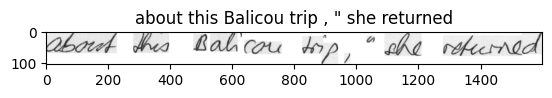

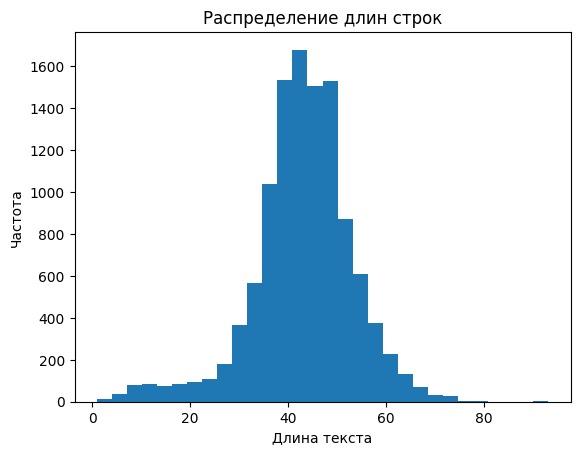

[' ', '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


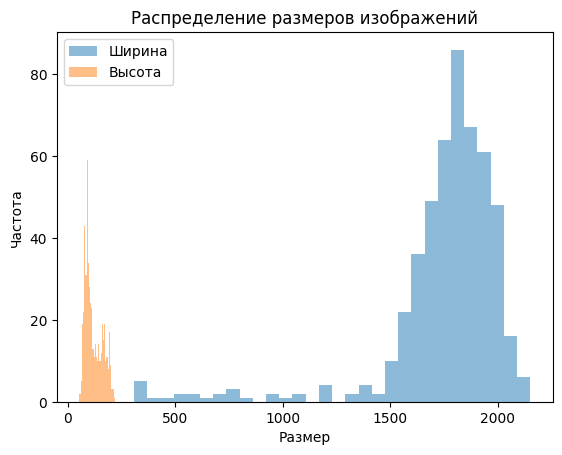

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

def visualize_sample(sample):
    img_path = sample["image_path"]
    bbox = sample["bbox"]
    transcription = sample["transcription"]

    try:
        img = Image.open(img_path).convert("RGB")
        plt.imshow(img)
        plt.title(transcription)
        # plt.axis('off')
        plt.show()
    except Exception as e:
        print(f"Ошибка при загрузке изображения: {e}")

# Example visualization
visualize_sample(data_samples[10000])


# Text length distribution
text_lengths = [len(sample["transcription"]) for sample in data_samples]

plt.hist(text_lengths, bins=30)
plt.xlabel("Длина текста")
plt.ylabel("Частота")
plt.title("Распределение длин строк")
plt.show()


# Chars exploration
all_chars = set()
for sample in data_samples:
    all_chars.update(sample["transcription"])
print(sorted(all_chars))


# Sizes of images
img_widths = []
img_heights = []
for sample in data_samples[:500]:
    img_path = sample["image_path"]
    try:
        img = Image.open(img_path)
        img_widths.append(img.width)
        img_heights.append(img.height)
    except Exception as e:
        print(f"Ошибка при загрузке изображения: {e}")

plt.hist(img_widths, bins=30, alpha=0.5, label="Ширина")
plt.hist(img_heights, bins=30, alpha=0.5, label="Высота")
plt.xlabel("Размер")
plt.ylabel("Частота")
plt.title("Распределение размеров изображений")
plt.legend()
plt.show()

### Encode text

In [10]:
class CharacterMapper:
    def __init__(self, samples):
        unique_chars = set()
        for sample in samples:
            unique_chars.update(sample["transcription"])
        self.chars = sorted(unique_chars)

        self.char_to_idx = {char: idx + 1 for idx, char in enumerate(self.chars)}
        self.idx_to_char = {idx + 1: char for idx, char in enumerate(self.chars)}
        self.idx_to_char[0] = ""

        self.num_classes = len(self.chars) + 1

    def encode(self, text):
        indices = []
        for char in text:
            if char in self.char_to_idx:
                indices.append(self.char_to_idx[char])
        return indices

    def decode(self, indices):
        chars = []
        prev_idx = None
        for idx in indices:
            if idx != 0 and idx != prev_idx and idx in self.idx_to_char:
                chars.append(self.idx_to_char[idx])
            prev_idx = idx
        return ''.join(chars)

mapper = CharacterMapper(data_samples)
print(f"Уникальных символов: {mapper.num_classes}")
test_text = "Hello myy friend"
encoded = mapper.encode(test_text)
decoded = mapper.decode(encoded)
print(f"\nТест: '{test_text}' → {encoded} → '{decoded}'")

Уникальных символов: 80

Тест: 'Hello myy friend' → [35, 58, 65, 65, 68, 1, 66, 78, 78, 1, 59, 71, 62, 58, 67, 57] → 'Helo my friend'


### Prepare dataset to load into CRNN

In [11]:
from torch.utils.data import Dataset, DataLoader

class IAMDataset(Dataset):
    def __init__(self, samples, char_mapper, img_height=64):
        self.samples = samples
        self.char_mapper = char_mapper
        self.img_height = img_height

    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample["image_path"]).convert("L")

        w, h = img.size
        new_w = int(self.img_height * w / h)
        img = img.resize((new_w, self.img_height), Image.Resampling.LANCZOS)

        img_array = np.array(img, dtype=np.float32) / 255.0
        img_array = (img_array - 0.5) / 0.5

        img_tensor = torch.FloatTensor(img_array).unsqueeze(0)

        target_ids = self.char_mapper.encode(sample["transcription"])
        target_tensor = torch.LongTensor(target_ids)

        return {
            "image": img_tensor,
            "target": target_tensor,
            "transcription": sample["transcription"],
            "img_path": sample["image_path"]
        }
    
def unify_size(batch):
    images = [item["image"] for item in batch]
    targets = [item["target"] for item in batch]
    texts = [item["transcription"] for item in batch]

    max_width = max(img.shape[2] for img in images)
    batch_size = len(images)
    height = images[0].shape[1]

    padded_images = torch.zeros(batch_size, 1, height, max_width)
    input_lengths = []

    for i, img in enumerate(images):
        w = img.shape[2]
        padded_images[i, :, :, :w] = img
        input_lengths.append(w)
    
    target_lengths = torch.LongTensor([len(t) for t in targets])
    targets_concatenated = torch.cat([t for t in targets])

    return {
        "images": padded_images,
        "targets": targets_concatenated,
        "target_lengths": target_lengths,
        "input_lengths": torch.LongTensor(input_lengths),
        "texts": texts
    }
    

dataset = IAMDataset(data_samples, mapper)
sample = dataset[0]
print(f"Image shape: {sample['image'].shape}")
print(f"Original text: {sample['transcription']}")


train_ratio = 0.9
train_size = max(1, int(len(dataset) * train_ratio))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(52)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False,
                          collate_fn=unify_size, num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        collate_fn=unify_size, num_workers=0)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

batch = next(iter(train_loader))
print(f"Batch images shape: {batch['targets'].shape}")


Image shape: torch.Size([1, 64, 1194])
Original text: A MOVE to stop Mr. Gaitskell from
Train samples: 10209, Validation samples: 1135
Batch images shape: torch.Size([332])


## CRNN

In [12]:
class CRNN(nn.Module):
    """CNN-BiLSTM-CTC"""
    
    def __init__(self, img_height=64, num_chars=80, hidden_size=256, num_layers=2):
        super(CRNN, self).__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d((2, 1)),

            nn.Conv2d(512, 512, kernel_size=2),
            nn.BatchNorm2d(512),
            nn.ReLU(),     
        )

        self.map_to_seq = nn.LazyLinear(hidden_size)

        self.rnn = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            dropout=0.3 if num_layers > 1 else 0,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size * 2, num_chars + 1)

    def forward(self, x):
        conv = self.cnn(x)
        b, c, h, w = conv.size()

        conv = conv.permute(0, 3, 1, 2).reshape(b, w, c * h)

        seq = self.map_to_seq(conv)
        rnn_out, _ = self.rnn(seq)
        output = self.fc(rnn_out)
        return torch.nn.functional.log_softmax(output, dim=2)
    
    
model = CRNN(
    img_height=64,
    num_chars=mapper.num_classes,
    hidden_size=256,
    num_layers=2
)
model = model.to(device)

with torch.no_grad():
    _ = model(torch.randn(1, 1, 64, 256).to(device))

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params}")

Model parameters: 8617937


### Decode and evaluate

In [ ]:
def decode_predictions(outputs, char_mapper):
    _, max_indices = torch.max(outputs, dim=2)
    predictions = []
    for seq in max_indices:
        text = char_mapper.decode(seq.cpu().numpy())
        predictions.append(text)
    return predictions


def ctc_input_lengths_from_padded_images(widths, max_t):
    lens = widths // 4 - 1
    lens = torch.clamp(lens, min=1, max=max_t)
    return lens


def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)

    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]


def calculate_CER(prediction, ground_truth):
    if len(ground_truth) == 0:
        return 0.0 if len(prediction) == 0 else 1.0
    return levenshtein_distance(prediction, ground_truth) / len(ground_truth)

def calculate_WER(prediction, ground_truth):
    pred_words = prediction.split()
    gt_words = ground_truth.split()
    if len(gt_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0
    return levenshtein_distance(pred_words, gt_words) / len(gt_words)


def train_epoch(model, train_loader, criterion, optimizer, device, scaler=None):
    model.train()
    total_loss = 0.0
    num_batches = len(train_loader)
    use_amp = scaler is not None and device.type == "cuda"

    for batch_idx, batch in enumerate(train_loader):
        images = batch["images"].to(device, non_blocking=True)
        targets = batch["targets"].to(device, non_blocking=True)
        target_lengths = batch["target_lengths"].to(device, non_blocking=True)
        raw_widths = batch["input_lengths"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            input_lengths = ctc_input_lengths_from_padded_images(raw_widths, outputs.size(1))
            outputs_ctc = outputs.permute(1, 0, 2)
            loss = criterion(outputs_ctc, targets, input_lengths, target_lengths)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 20 == 0 or (batch_idx + 1) == num_batches:
            print(f"Batch {batch_idx + 1}/{num_batches}, Loss: {loss.item():.4f}")

    return total_loss / max(1, num_batches)


def validate(model, val_loader, criterion, char_mapper, device):
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_ground_truths = []
    total_cer = 0.0
    total_wer = 0.0
    num_samples = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch["images"].to(device, non_blocking=True)
            targets = batch["targets"].to(device, non_blocking=True)
            target_lengths = batch["target_lengths"].to(device, non_blocking=True)
            raw_widths = batch["input_lengths"].to(device, non_blocking=True)
            texts = batch["texts"]

            outputs = model(images)
            input_lengths = ctc_input_lengths_from_padded_images(raw_widths, outputs.size(1))

            outputs_ctc = outputs.permute(1, 0, 2)
            loss = criterion(outputs_ctc, targets, input_lengths, target_lengths)
            total_loss += loss.item()

            predictions = decode_predictions(outputs, char_mapper)
            all_predictions.extend(predictions)
            all_ground_truths.extend(texts)

            for pred, gt in zip(predictions, texts):
                total_cer += calculate_CER(pred, gt)
                total_wer += calculate_WER(pred, gt)
                num_samples += 1

    avg_loss = total_loss / max(1, len(val_loader))
    avg_cer = total_cer / max(1, num_samples)
    avg_wer = total_wer / max(1, num_samples)
    return avg_loss, avg_cer, avg_wer, all_predictions, all_ground_truths

In [ ]:
import os
import torch.optim as optim

if "dataset" not in globals():
    if "data_samples" not in globals() or "mapper" not in globals():
        raise ValueError("Нет данных для создания датасета. Запустите верхние ячейки кода")
    dataset = IAMDataset(data_samples, mapper)

if "train_dataset" not in globals() or "val_dataset" not in globals():
    train_ratio = 0.9
    train_size = max(1, int(len(dataset) * train_ratio))
    val_size = len(dataset) - train_size

    generator = torch.Generator().manual_seed(52)
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

batch_size = 16 if device.type == "cuda" else 8
num_workers = min(4, os.cpu_count() or 1)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=unify_size,
    num_workers=num_workers,
    pin_memory=(device.type == 'cuda')
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=unify_size,
    num_workers=num_workers,
    pin_memory=(device.type == 'cuda')
)

print(f"Batch size: {batch_size}, workers: {num_workers}")
print(f"Train batches: {len(train_loader)}, Validation batches: {len(val_loader)}")

Train samples: 10209, Validation samples: 1135
Train batches: 1277, Validation batches: 142


In [ ]:
EPOCHS = 40
LEARNING_RATE = 3e-4
PATIENCE = 8

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

model = model.to(device)

resume_candidates = [
    Path("crnn_checkpoint_last.pth"),
    Path("crnn_checkpoint_best.pth")
]
resume_path = next((p for p in resume_candidates if p.exists()), None)

criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

history = {
    "train_loss": [],
    "val_loss": [],
    "val_cer": [],
    "val_wer": [],
    "best_val_cer": float("inf"),
    "best_epoch": 0,
}

best_checkpoint_path = Path("crnn_checkpoint_best.pth")
last_checkpoint_path = Path("crnn_checkpoint_last.pth")
final_checkpoint_path = Path("crnn_checkpoint_last.pth")

start_epoch = 1
epochs_no_improve = 0

if resume_path is not None:
    try:
        print(f"Загрузка контрольной точки из: {resume_path}")
        checkpoint = torch.load(resume_path, map_location=device, weights_only=False)

        if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])

            if "optimizer_state_dict" in checkpoint:
                optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            if "history" in checkpoint and isinstance(checkpoint["history"], dict):
                history = checkpoint["history"]
            if "epoch" in checkpoint:
                start_epoch = int(checkpoint["epoch"]) + 1
            if "best_val_cer" in history:
                best_val_cer = history["best_val_cer"]
            else:
                best_val_cer = float("inf")
            history["best_val_cer"] = best_val_cer
            print(f"Контрольная точка загружена. Продолжаем с эпохи {start_epoch}.")
        else:
            model.load_state_dict(checkpoint)
            print("Загружен state_dict без состояния оптимизатора.")
    except TypeError:
        # Для старых версий torch без weights_only
        checkpoint = torch.load(resume_path, map_location=device)
        if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
            model.load_state_dict(checkpoint["model_state_dict"])
            if "optimizer_state_dict" in checkpoint:
                optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            if "history" in checkpoint and isinstance(checkpoint["history"], dict):
                history = checkpoint["history"]
            if "epoch" in checkpoint:
                start_epoch = int(checkpoint["epoch"]) + 1
            print(f"Контрольная точка загружена. Продолжаем с эпохи {start_epoch}.")
        else:
            model.load_state_dict(checkpoint)
            print("Загружен state_dict без состояния оптимизатора.")
    except Exception as e:
        print(f"Ошибка при загрузке контрольной точки: {e}")
        print("Продолжаем обучение с нуля.")
else:
    print("Контрольная точка не найдена. Начало обучения с нуля.")

# Если уже прошли все эпохи, делаем еще 10 дообучения
if start_epoch > EPOCHS:
    EPOCHS = start_epoch + 10
    print(f"Увеличиваю EPOCHS до {EPOCHS} для дообучения.")

print(f"Начало обучения... Устройство: {device}")

for epoch in range(start_epoch, EPOCHS + 1):
    print("\n" + "=" * 30)
    print(f"Эпоха {epoch}/{EPOCHS}")
    print("=" * 30)

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scaler=scaler)
    history["train_loss"].append(train_loss)
    print(f"Средняя потеря на обучении: {train_loss:.4f}")

    val_loss, val_cer, val_wer, predictions, ground_truths = validate(
        model, val_loader, criterion, mapper, device
    )
    history["val_loss"].append(val_loss)
    history["val_cer"].append(val_cer)
    history["val_wer"].append(val_wer)

    print(f"Средняя потеря на валидации: {val_loss:.4f}")
    print(f"Средняя CER на валидации: {val_cer:.4f}")
    print(f"Средняя WER на валидации: {val_wer:.4f}")

    print("\nПримеры предсказаний:")
    shown = min(5, len(ground_truths), len(predictions))
    for i in range(shown):
        print(f"GT: '{ground_truths[i]}' -> Pred: '{predictions[i]}'")

    if val_cer < history["best_val_cer"]:
        history["best_val_cer"] = val_cer
        history["best_epoch"] = epoch
        epochs_no_improve = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "char_mapper": mapper,
                "history": history,
                "val_cer": val_cer,
                "val_wer": val_wer,
            },
            best_checkpoint_path,
        )
        print(f"Новая лучшая модель сохранена: {best_checkpoint_path} (CER: {val_cer:.4f})")
    else:
        epochs_no_improve += 1
        print(f"Нет улучшения CER. Эпох без улучшения: {epochs_no_improve}/{PATIENCE}")

    # Сохраняем последнюю точку на каждой эпохе
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "char_mapper": mapper,
            "history": history,
        },
        last_checkpoint_path,
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Текущий learning rate: {current_lr:.7f}")

    if epochs_no_improve >= PATIENCE:
        print("Раннее прекращение обучения из-за отсутствия улучшения CER.")
        break

print("\nОбучение завершено.")
if history["train_loss"]:
    print(f"Итоговый loss на обучении: {history['train_loss'][-1]:.4f}")
if history["val_loss"]:
    print(f"Итоговый loss на валидации: {history['val_loss'][-1]:.4f}")
print(f"Лучший CER на валидации: {history['best_val_cer']:.4f} (эпоха {history['best_epoch']})")
if history["val_wer"]:
    print(f"Итоговый WER на валидации: {history['val_wer'][-1]:.4f}")
print("=" * 30)

torch.save(
    {
        "epoch": len(history["train_loss"]),
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "char_mapper": mapper,
        "history": history,
    },
    final_checkpoint_path,
)
print(f"Последнее состояние модели сохранено в '{final_checkpoint_path}'")

Контрольная точка не найдена. Начало обучения с нуля.
Начало обучения... Устройство: cuda

Эпоха 1/10
Batch 10/1277, Loss: 6.5382
Batch 20/1277, Loss: 3.7829
Batch 30/1277, Loss: 3.4163
Batch 40/1277, Loss: 3.2186
Batch 50/1277, Loss: 3.1855
Batch 60/1277, Loss: 3.0989
Batch 70/1277, Loss: 3.1871
Batch 80/1277, Loss: 3.1357
Batch 90/1277, Loss: 3.1610
Batch 100/1277, Loss: 3.2307
Batch 110/1277, Loss: 3.1523
Batch 120/1277, Loss: 3.3291
Batch 130/1277, Loss: 3.1640
Batch 140/1277, Loss: 3.0926
Batch 150/1277, Loss: 3.0739
Batch 160/1277, Loss: 3.1530
Batch 170/1277, Loss: 3.1894
Batch 180/1277, Loss: 3.0207
Batch 190/1277, Loss: 3.1534
Batch 200/1277, Loss: 3.0665
Batch 210/1277, Loss: 3.0743
Batch 220/1277, Loss: 3.1937
Batch 230/1277, Loss: 3.3075
Batch 240/1277, Loss: 3.1426
Batch 250/1277, Loss: 3.2763
Batch 260/1277, Loss: 3.0475
Batch 270/1277, Loss: 3.1789
Batch 280/1277, Loss: 3.1103
Batch 290/1277, Loss: 3.1238
Batch 300/1277, Loss: 3.1106
Batch 310/1277, Loss: 3.1630
Batch 32

###  Inference

In [34]:
from pathlib import Path
from PIL import Image
import numpy as np
import torch

checkpoint_path = Path().resolve() / "crnn_checkpoint_best.pth"

try:
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
except TypeError:
    ckpt = torch.load(checkpoint_path, map_location=device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state_dict = ckpt["model_state_dict"]
    mapper_for_infer = ckpt.get("char_mapper", mapper)
else:
    state_dict = ckpt
    mapper_for_infer = mapper

infer_model = CRNN(
    img_height=64,
    num_chars=mapper_for_infer.num_classes,
    hidden_size=256,
    num_layers=2
).to(device)

infer_model.load_state_dict(state_dict)
infer_model.eval()

def preprocess_one_image(image_path, img_height=64):
    img = Image.open(image_path).convert("L")
    w, h = img.size
    new_w = max(4, int(img_height * w / h))
    img = img.resize((new_w, img_height), Image.Resampling.LANCZOS)

    arr = np.array(img, dtype=np.float32) / 255.0
    arr = (arr - 0.5) / 0.5  # как в обучении
    tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
    return tensor

def predict_text(image_path):
    x = preprocess_one_image(image_path).to(device)
    with torch.no_grad():
        outputs = infer_model(x)            # [1, T, C]
        pred = decode_predictions(outputs, mapper_for_infer)[0]
    return pred

my_image = "128.jpg"
pred_text = predict_text(my_image)

print("Image:", my_image)
print("Prediction:", pred_text)

Image: 128.jpg
Prediction: TThe saered  geamezry  of (chance . 
